# 第十一週：Text Embeddings

本週課程為「Text Embeddings」，主要會使用到gensim套件來實現自行訓練word2vec模型以及使用預訓練word2vec模型，以及透過sentence-transformers套件和API取得embeddings。

### 大綱：
1.   DEMO
*   Word2Vec
  *   自己訓練w2v模型
  *   使用別人訓練好的w2v模型
*   Transformers Embeddings
  *   小模型（BERT）：
      *   不同語言的BERT：uncased / chinese / multilingual
  *   大模型（LLM）：
      *   API based
      *   Open Source LLM  

2.   資料集實作任務
*    使用embedding 做 NLP 任務
  *   找相似文件（文章）
  *   文件分類任務


### 套件安裝

連接雲端資料夾

In [1]:
# import os

# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# os.chdir('雲端資料夾路徑') #切換該目錄
# os.listdir() #確認目錄內容

In [3]:
# !pip install jieba
# !pip install "gensim==4.3.3" "spacy==3.7.2" "thinc==8.2.2"

如果安裝套件時遇到跟 numpy 相關錯誤的話，可以嘗試執行以下程式碼

In [4]:
# # 先清除舊的 numpy
# !pip uninstall -y numpy

# # 安裝對應版本
# !pip install numpy==1.26.4 gensim==4.3.3 spacy==3.7.2 thinc==8.2.2

# # 強制重啟 Runtime
# import os
# os.kill(os.getpid(), 9)

In [5]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors


import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

c:\Users\lcswa\anaconda3\envs\nlp_env\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 資料前處理

讀入吃到飽示範資料集

In [6]:
# 設定繁體中文詞庫
jieba.set_dictionary('dict\dict.txt')
jieba.load_userdict('./dict/user_dict.txt')

# 新增stopwords
with open('./dict/stopwords.txt',encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

Building prefix dict from c:\Users\lcswa\Desktop\code\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\lcswa\AppData\Local\Temp\jieba.uc1d48b1a905c8860090319444c7f7315.cache
Loading model cost 0.687 seconds.
Prefix dict has been built successfully.


In [7]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [8]:
# 讀入中文示範資料集
origin_data = pd.read_csv('raw_data/starlux_dataset.csv')

In [9]:
# 資料前處理

# 去除一些不需要的欄位
# metaData = origin_data.drop(['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], axis=1)
# 修改後的寫法
metaData = origin_data.drop(
    ['artPoster', 'artCatagory', 'artComment', 'e_ip', 'insertedDate', 'dataSource'], 
    axis=1, 
    errors='ignore'
)
# 只留下中文字
metaData['sentence'] = metaData['artContent'].str.replace(r'\n\n','。', regex=True)
metaData['sentence'] = metaData['sentence'].str.replace(r'\n','', regex=True)

metaData['sentence'] = metaData['sentence'].str.split("[,，。！!？?]{1,}")
metaData = metaData.explode('sentence').reset_index(drop=True)

metaData['sentence'] = metaData['sentence'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

metaData['word'] = metaData.sentence.apply(getToken)

metaData = metaData[metaData['word'].apply(len) > 0]

metaData.head(10)

,system_id,board,artTitle,artUrl,artDate,rowType,artContent,sentence,word
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢,"[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]"
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星宇累計的里程和星加坡長榮應該是分開的,"[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]"
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話,[位置]
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢還是都用班機時刻選請問大家會怎麼選感謝,"[這三家, 班機, 時刻, 請問, 感謝]"
4,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的,"[這有, 糾結]"
5,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,你沒高卡沒哩程需求就是選便宜的啊,"[沒高卡, 哩程, 需求, 便宜]"
6,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,"[星宇, 看到, 托運, 一件, 最近, 注意到]"
7,3,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:54,comment,金城武都選長榮 你參考,金城武都選長榮你參考,"[金城武, 長榮, 參考]"
8,4,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 17:09,comment,非哩程卡客就挑便宜的啊 為什麼便宜可能剛好低價票還有或設定促銷票給你看到,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到,"[哩程, 卡客, 便宜, 便宜, 低價票, 設定, 促銷, 票給, 看到]"
10,6,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 18:28,comment,台灣新加坡航線，不管什麼航空基本票價都是一件行李,台灣新加坡航線,"[台灣, 新加坡, 航線]"


### word2vec


####（1）如何自己訓練word2vec模型

建立訓練資料時將考慮bigram，以下為Phrases函式的使用示範

In [10]:
docs = ['new york is united states', 'new york is most populated city in the world','i love to stay in new york']

token_ = [doc.split(" ") for doc in docs]
# Phrases 建立bigram,
# 少於min_count的字的字或bigrams會被忽略,
# 大於threshold的bigrams會被加入
bigram = Phrases(token_, min_count=1, threshold=2)
bigram_phraser = Phraser(bigram)

for sent in token_:
    print(sent)  #處理前
    print("=> ",bigram_phraser[sent]) # 處理後，還是原本的句子，只是有抓出的bigram片語會被合併

['new', 'york', 'is', 'united', 'states']
=>  ['new_york', 'is', 'united', 'states']
['new', 'york', 'is', 'most', 'populated', 'city', 'in', 'the', 'world']
=>  ['new_york', 'is', 'most', 'populated', 'city', 'in', 'the', 'world']
['i', 'love', 'to', 'stay', 'in', 'new', 'york']
=>  ['i', 'love', 'to', 'stay', 'in', 'new_york']


實際應用在資料集上

In [11]:
sents = metaData['word'].to_list()
bigrams = Phrases(sents,min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams)
metaData['word_list_bigrams'] = list(bigram_phrasers[sents])

metaData.head()

,system_id,board,artTitle,artUrl,artDate,rowType,artContent,sentence,word,word_list_bigrams
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢,"[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]","[請問, 新加坡, 台灣, 星宇星, 加坡, 長榮]"
1,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星宇累計的里程和星加坡長榮應該是分開的,"[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]","[票價, 星宇, 便宜, 明白, 那麼多, 選星宇, 累計, 里程, 加坡, 長榮, 分開]"
2,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,論位置的話,[位置],[位置]
3,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,這三家哪個會比較大呢還是都用班機時刻選請問大家會怎麼選感謝,"[這三家, 班機, 時刻, 請問, 感謝]","[這三家, 班機, 時刻, 請問, 感謝]"
4,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的,"[這有, 糾結]","[這有, 糾結]"


In [12]:
word_freq = defaultdict(int)
# 計算詞頻
sents = metaData['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [13]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 10189


['星宇', '員工', '公司', '年終', '飛機', '華航', '長榮', '台中', '星宇航空', '航空']

In [14]:
print(f"sentence number of corpus: {len(sents)}")
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}")

sentence number of corpus: 9225
average length of sentences: 4.182655826558266


Word2Vec 計算

In [15]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [16]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 16


In [17]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=20,# 小於20次tf的字會被刪除
                     window=2,# 往左右各2的距離
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

查看結果

In [18]:
# 檢查最相關的字
w2v_model.wv.most_similar('飛機',topn=10)

[('長榮', 0.6566026210784912),
 ('公司', 0.6023849248886108),
 ('航空公司', 0.5915048122406006),
 ('知道', 0.582550585269928),
 ('日本', 0.582407534122467),
 ('精品', 0.5795705914497375),
 ('折舊', 0.5774229764938354),
 ('賺錢', 0.5756840109825134),
 ('現在', 0.5755881071090698),
 ('虎航', 0.5738298892974854)]

In [19]:
w2v_model.wv.most_similar('年終',topn=10)

[('公司', 0.8870556354522705),
 ('員工', 0.8820398449897766),
 ('引述', 0.8344380855560303),
 ('銘言', 0.8291600346565247),
 ('資方', 0.8281261324882507),
 ('台灣', 0.8245267271995544),
 ('不發', 0.8118223547935486),
 ('看到', 0.8112994432449341),
 ('國泰', 0.809370219707489),
 ('股票', 0.8026629090309143)]

In [20]:
w2v_model.wv.most_similar(['員工','年終'],topn=10)

[('公司', 0.9045560956001282),
 ('資方', 0.8418055772781372),
 ('引述', 0.8411371111869812),
 ('台灣', 0.8399748206138611),
 ('不發', 0.8389602899551392),
 ('銘言', 0.8316659331321716),
 ('看到', 0.8302065134048462),
 ('國泰', 0.8263270258903503),
 ('股票', 0.8249835968017578),
 ('罷工', 0.8205978274345398)]

In [21]:
# 跟兩個字最不相關
w2v_model.wv.most_similar(negative=['年終','飛機'],topn=10)

[('旅客', 0.7241289019584656),
 ('新聞', 0.643745481967926),
 ('原文', 0.6135268807411194),
 ('桃園', 0.5791587829589844),
 ('發現', 0.5108382105827332),
 ('客人', 0.4601694941520691),
 ('加入', 0.4147312343120575),
 ('尤其', 0.41467446088790894),
 ('競爭', 0.38797882199287415),
 ('原來', 0.38693296909332275)]

In [22]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("年終","長榮")

0.6406961

In [23]:
w2v_model.wv.similarity("星宇","飛機")

0.4472718

In [24]:
# 比較字詞間，誰最不相關（邊緣）
w2v_model.wv.doesnt_match(["年終", "星宇", '飛機'])

'飛機'

In [25]:
# 相對關係
w2v_model.wv.most_similar(positive=["年終"], negative=["星宇"], topn=5)

[('新創', 0.3324809670448303),
 ('日期', 0.3307669758796692),
 ('來源', 0.3198641836643219),
 ('老闆', 0.3186212182044983),
 ('共體時艱', 0.3022879958152771)]

In [26]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

視覺化字之間的關係及將字做分群

In [27]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


In [28]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [29]:
getVecs(w2v_model,['年終','星宇'])

array([[ 6.93147012e-04,  1.94607042e-02,  8.33782542e-04,
         1.87073201e-02,  3.35194133e-02, -1.25998687e-02,
         4.10390412e-03, -9.35276388e-04,  1.20048774e-02,
        -2.49538617e-03,  9.42414440e-03, -3.88302724e-03,
        -1.28165465e-02, -8.95810779e-03, -2.15974078e-02,
         3.86719778e-02,  1.42495036e-02,  1.32030975e-02,
        -9.68722999e-03,  1.13444971e-02, -1.24744205e-02,
        -1.86593533e-02,  1.81034617e-02, -4.40586433e-02,
        -6.50587818e-03,  2.24794336e-02, -2.40179151e-02,
         1.21261636e-02,  1.86837800e-02, -7.27394549e-03,
         1.20544080e-02,  1.80301182e-02,  4.26063416e-05,
         2.79465821e-02,  7.47069204e-03,  8.11087666e-04,
         1.22765480e-02, -2.29838993e-02, -1.24247558e-02,
        -2.47013313e-03,  2.13629175e-02, -1.30023891e-02,
         4.70438227e-03, -1.49604108e-03, -8.20332021e-03,
        -2.60432926e-03,  1.37989372e-02,  2.18571723e-02,
        -9.50120669e-03, -6.01097755e-03,  3.07265129e-0

In [30]:
# 擴展相似的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [31]:
expandPosWord(w2v_model,['年終','飛機'],top_n = 10)

['精品',
 '引述',
 '公司',
 '員工',
 '日本',
 '知道',
 '不發',
 '資方',
 '現在',
 '銘言',
 '台灣',
 '長榮',
 '航空公司',
 '虎航',
 '國泰',
 '股票',
 '賺錢',
 '折舊',
 '看到']

In [32]:
# 畫出兩維的散佈圖
def plotScatter(vec_df):
    """
    vec_df: 字詞及其兩個維度的值
    """
    plt.figure(figsize=(15,15))
    fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [33]:
# 查看總數
total_words = len(words)
print(f"目前詞庫總數：{total_words}")

# 查看前 20 個詞（確認過濾邏輯是否正確）
print("詞庫樣本：", list(words)[:20])

目前詞庫總數：318
詞庫樣本： ['星宇', '員工', '公司', '年終', '飛機', '華航', '長榮', '台中', '星宇航空', '航空', '罷工', '知道', '航線', '台灣', '現在', '賺錢', '問題', '日本', '商務艙', '頭等艙']


In [34]:
sample_words = np.random.choice(list(words),300,replace=False).tolist()

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 300)
print(new_feat.shape)

(300, 128)
(300, 2)


In [35]:
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
})

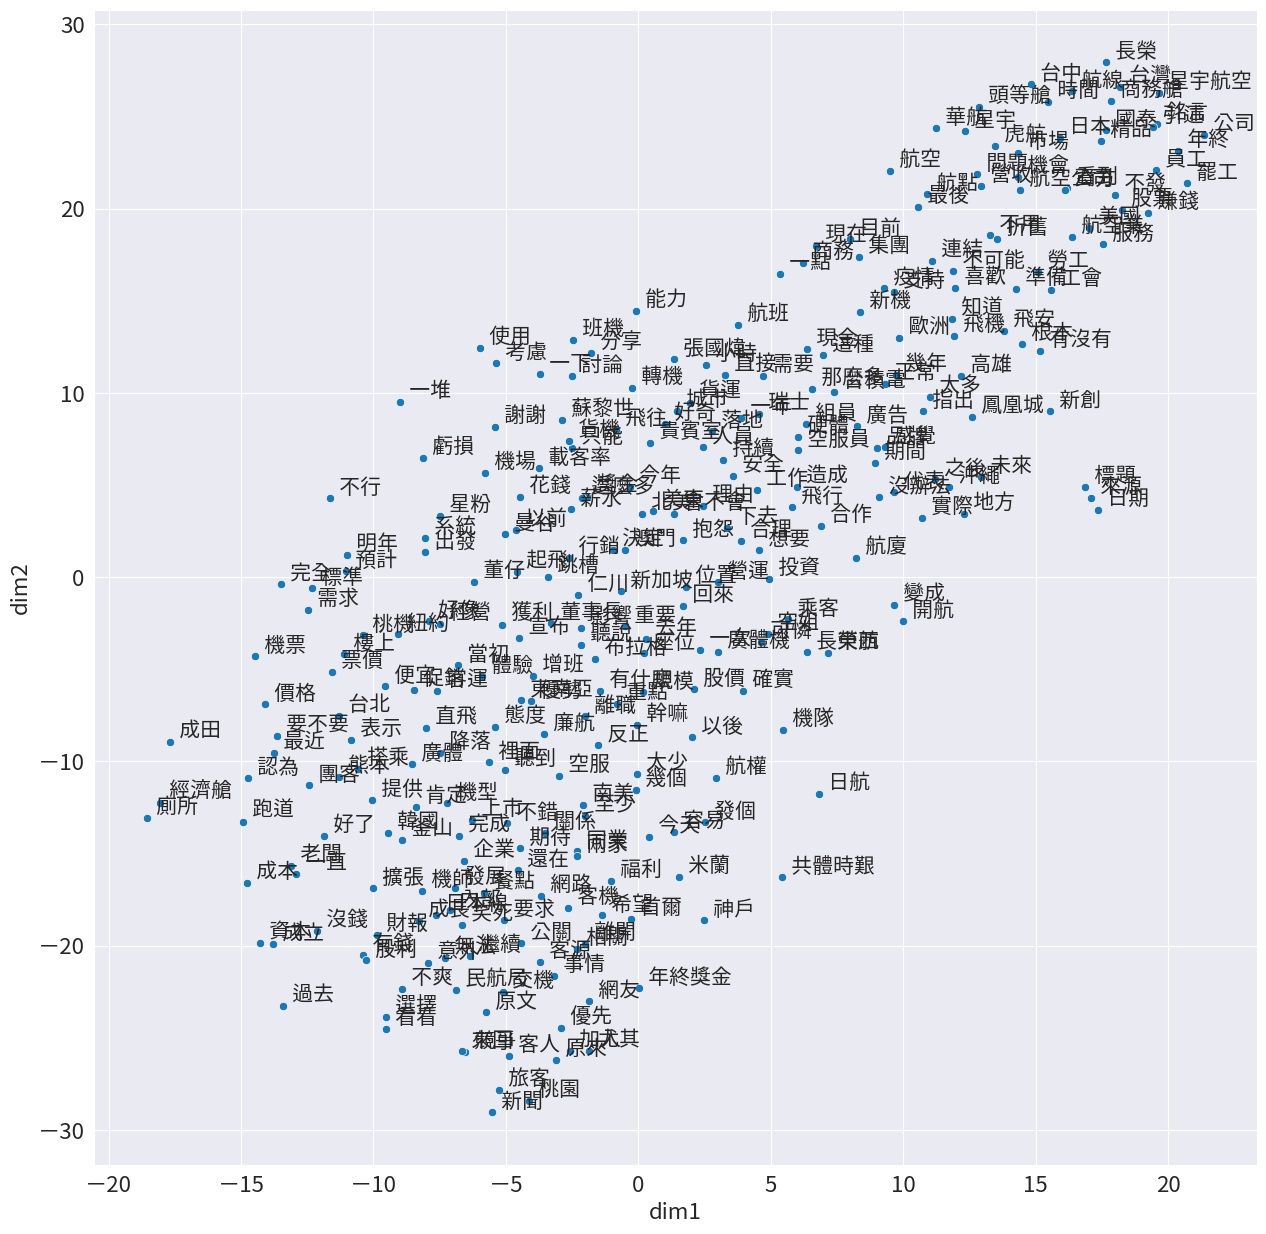

In [36]:
plotScatter(word_df)

3D 散狀圖

In [37]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)


將字分群

In [38]:
# !pip install scikit-learn-extra

In [ ]:
# kmeans分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result


In [40]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

### Transformers Embeddings

#### 使用 Sentence-Transformer 套件   
參考資料：https://www.sbert.net/index.html

In [41]:
# !pip install -U sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer, models, util

c:\Users\lcswa\anaconda3\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 小模型，以BERT為範例

註：在挑選語言模型時需確認其訓練資料的來源，因為不一定都具備跨語言的能力。   
接下來將以針對英文、中文以及多語言進行訓練的三種BERT模型做範例。

In [ ]:
# 英文 bert-base-uncased
bert_en = SentenceTransformer('google-bert/bert-base-uncased')

bert_en.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

c:\Users\lcswa\anaconda3\envs\nlp_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lcswa\.cache\huggingface\hub\models--google-bert--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5849.47it/s]
[transformers] BertModel LOAD RE

0

In [ ]:
bert_en.get_max_seq_length()

512

In [ ]:
example_text = "This framework generates embeddings for each input sentence"
example_embeddings = bert_en.encode(example_text)

print(example_embeddings.shape)
print("=======================")
print(example_embeddings)

(768,)
[-1.25634402e-01 -2.35389136e-02  9.72143114e-02 -2.14601725e-01
 -4.24762517e-02 -7.68906111e-03  1.66509300e-01  2.09751531e-01
  1.94057211e-01 -9.31544602e-02 -1.04051284e-01 -1.99633732e-01
 -3.48384172e-01  8.10463950e-02 -1.62067898e-02  1.90525979e-01
  5.29560901e-04  1.45439580e-01 -5.54185652e-04 -1.58490971e-01
  1.94275454e-01  1.59165367e-01 -5.99901080e-01  2.65522033e-01
  7.47946203e-01 -2.46574776e-03  1.04437150e-01  1.66958198e-01
 -3.53779256e-01  1.39418632e-01  3.89940999e-02  6.57110214e-01
 -6.23257132e-03 -2.85023957e-01 -1.56141028e-01  8.45850632e-02
  1.65655315e-01 -2.55370378e-01 -1.16442516e-01  9.59288701e-02
 -6.72327101e-01 -3.47995222e-01  8.42585489e-02 -2.06027567e-01
 -5.32227531e-02 -4.90706593e-01 -9.41106025e-03 -3.81040931e-01
  5.67960478e-02 -6.35588050e-01 -1.04700708e+00  3.73333305e-01
  1.31077543e-01  3.08176249e-01 -2.27984011e-01  8.04124236e-01
  1.21666618e-01 -7.21640527e-01  3.69301528e-01 -1.17350541e-01
  1.25593171e-01 -

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence",
    "The quick brown fox jumps over the lazy dog.",
    "The speedy black dog leaps across the cat."
]

# 使用 encode() 對資料做embedding
embeddings_en = bert_en.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_en, embeddings_en)

# 印出句子間的cosine similarity分數
result = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        result.append([sentences[i], sentences[j], cosine_scores[i][j].item()])

result_df = pd.DataFrame(result, columns=["sentence1", "sentence2", "score"])
result_df.sort_values("score", ascending = False)

,sentence1,sentence2,score
2,The quick brown fox jumps over the lazy dog.,The speedy black dog leaps across the cat.,0.880907
0,This framework generates embeddings for each i...,The quick brown fox jumps over the lazy dog.,0.499376
1,This framework generates embeddings for each i...,The speedy black dog leaps across the cat.,0.480858


因為後續在查看結果時會一直使用到此程式碼，所以包成function以便之後使用。

In [ ]:
# 回傳cosine similarity分數
def get_result_df(sentences, cosine_scores):

  result = []
  for i in range(len(sentences)):
      for j in range(i+1, len(sentences)):
          result.append([sentences[i], sentences[j], cosine_scores[i][j].item()])

  result_df = pd.DataFrame(result, columns=["sentence1", "sentence2", "score"])
  result_df = result_df.sort_values("score", ascending = False)

  return result_df

中文 bert-base-chinese

In [ ]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

c:\Users\lcswa\anaconda3\envs\nlp_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lcswa\.cache\huggingface\hub\models--google-bert--bert-base-chinese. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7158.37it/s]
[transformers] BertModel LOAD RE

0

In [ ]:
# 示範句子
sentences = [
    "今天天氣很好。",
    "今天是個晴空萬里的好天氣。",
    "我晚上想去公園散步。"
]

# 使用 encode() 對資料做embedding
embeddings_ch = bert_ch.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_ch, embeddings_ch)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

,sentence1,sentence2,score
0,今天天氣很好。,今天是個晴空萬里的好天氣。,0.914067
1,今天天氣很好。,我晚上想去公園散步。,0.787590
2,今天是個晴空萬里的好天氣。,我晚上想去公園散步。,0.759642


多語言 bert-base-multilingual-cased

In [ ]:
# 多語言 bert-base-multilingual-cased
bert_multi = SentenceTransformer('google-bert/bert-base-multilingual-cased')

bert_multi.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

c:\Users\lcswa\anaconda3\envs\nlp_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lcswa\.cache\huggingface\hub\models--google-bert--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4678.05it/s]
[transformers] BertMo

0

In [ ]:
# 示範句子
sentences = [
    "This framework generates embeddings for each input sentence.",
    "The quick brown fox jumps over the lazy dog.",
    "敏捷的棕色狐狸跳過了懶惰的狗。"
]

# 使用 encode() 對資料做embedding
embeddings_multi = bert_multi.encode(sentences)

# Compute cosine-similarities
cosine_scores = util.cos_sim(embeddings_multi, embeddings_multi)

# 印出句子間的cosine similarity分數
result_df = get_result_df(sentences, cosine_scores)
result_df

,sentence1,sentence2,score
2,The quick brown fox jumps over the lazy dog.,敏捷的棕色狐狸跳過了懶惰的狗。,0.588525
1,This framework generates embeddings for each i...,敏捷的棕色狐狸跳過了懶惰的狗。,0.362765
0,This framework generates embeddings for each i...,The quick brown fox jumps over the lazy dog.,0.350699


#### 大模型範例

In [ ]:
# !pip install tiktoken
# !pip install utils

#### (1)API based

##### OpenAI

**注意**   
Openai的API會要求綁定信用卡後才能使用，且綁定信用卡後會刷5美金的初始費用。   
請自行斟酌是否要嘗試這一部分的程式碼！


In [ ]:
# !pip install --upgrade openai

In [ ]:
# from openai import OpenAI
# import openai
# import os

# openai.api_key = '你的API_KEY' # 設置API_KEY

# def get_embedding_openai(text, model):
#    #text = text.replace("\n", " ")
#    return openai.embeddings.create(input = [text], model=model).data[0].embedding

In [ ]:
embedding_model = "text-embedding-3-small"
embedding_encoding = "cl100k_base"
max_tokens = 8000  # the maximum for text-embedding-3-small is 8191

In [ ]:
# # 示範句子
# # sentences = [
# #     "This framework generates embeddings for each input sentence.",
# #     "The quick brown fox jumps over the lazy dog.",
# #     "敏捷的棕色狐狸跳過了懶惰的狗。",
# #     "速い茶色のキツネが怠惰な犬を飛び越える"
# # ]

# # # 取得每一句的embedding
# # embeddings_openai = [get_embedding_openai(text, model=embedding_model) for text in sentences]

# # Compute cosine-similarities
# cosine_scores = util.cos_sim(embeddings_openai, embeddings_openai)

# # 印出句子間的cosine similarity分數
# result_df = get_result_df(sentences, cosine_scores)
# result_df

##### Cohere

In [ ]:
# !pip install cohere

In [ ]:
# import cohere

# co = cohere.Client("你的API_KEY") # 設置API_KEY

# embedding_model = "embed-multilingual-v3.0"

# def get_embedding_cohere(text, model):
#    #text = text.replace("\n", " ")
#    return co.embed(texts=[text], model=model, input_type="classification").embeddings[0]

In [ ]:
# # 示範句子
# sentences = [
#     "This framework generates embeddings for each input sentence.",
#     "The quick brown fox jumps over the lazy dog.",
#     "敏捷的棕色狐狸跳過了懶惰的狗。",
#     "速い茶色のキツネが怠惰な犬を飛び越える"
# ]

# # 使用 encode() 對資料做embedding
# embeddings_cohere = [get_embedding_cohere(text, model=embedding_model) for text in sentences]

# # Compute cosine-similarities
# cosine_scores = util.cos_sim(embeddings_cohere, embeddings_cohere)

# # 印出句子間的cosine similarity分數
# result_df = get_result_df(sentences, cosine_scores)
# result_df

#### (2) Open Source LLM

In [ ]:
# from huggingface_hub import notebook_login
# notebook_login() # 輸入Hugging Face 帳號的Token

##### Microsoft - Phi 4

In [ ]:
# # model_phi3 = SentenceTransformer('microsoft/Phi-3.5-mini-instruct')
# model_phi4 = SentenceTransformer('microsoft/Phi-4-mini-instruct')

# model_phi4.tokenizer.pad_token = model_phi4.tokenizer.eos_token

In [ ]:
# # 示範句子
# sentences = [
#     "This framework generates embeddings for each input sentence",
#     "The quick brown fox jumps over the lazy dog.",
#     "The speedy black dog leaps across the cat."
# ]

# # 使用 encode() 對資料做embedding
# embeddings_phi4 = model_phi4.encode(sentences)

# # Compute cosine-similarities
# cosine_scores = util.cos_sim(embeddings_phi4, embeddings_phi4)

# # 印出句子間的cosine similarity分數
# result_df = get_result_df(sentences, cosine_scores)
# result_df

這裡需注意一下，上述的開源LLM基本上是decoder-only，它們主要的任務目標是要生成下一個字，並不是主要拿來做sentence embedding的。   
有興趣的同學可以參考[embedding相關任務的leaderboard](https://huggingface.co/spaces/mteb/leaderboard)，試試上面的模型。

### 使用embedding做NLP任務

#### 相似文件

In [ ]:
df_similar = origin_data[['system_id','artTitle', 'artContent']]
df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

,system_id,artTitle,artContent
0,0,[問題] 星宇 華航 新加坡 航空選擇,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...
1,1,[問題] 星宇 華航 新加坡 航空選擇,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊
2,2,[問題] 星宇 華航 新加坡 航空選擇,星宇你應該是看到只能托運一件的我最近也有注意到
3,3,[問題] 星宇 華航 新加坡 航空選擇,金城武都選長榮你參考
4,4,[問題] 星宇 華航 新加坡 航空選擇,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到


使用 bert-base-chinese 做示範

In [ ]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese', device='cuda')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7784.83it/s]
[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AssertionError: Torch not compiled with CUDA enabled

取得整個文集的 embeddings

In [ ]:
corpus_embeddings = bert_ch.encode(
    df_similar['artContent'],
    convert_to_tensor=True,
    batch_size=32
)

In [ ]:
query_num = 6 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")

In [ ]:
query_num = 30

top_k = 5

query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")